In [1]:
# Importing the libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importing the dataset.
Dataset = pd.read_csv("Titanic-Dataset.csv")
Dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 1. Dataset Information

In [3]:
print(Dataset.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
# Titanic dataset information.
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 2. Handling NAN/Missing values in a dataset.

In [5]:
# Checking the NAN/Missing Values.
print(Dataset.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Age – Replace missing values with median
Dataset['Age'].fillna(Dataset['Age'].median(), inplace=True)
Dataset['Age'] =  Dataset['Age'].astype(int)
Dataset['Age']

C:\Users\nandh\AppData\Local\Temp\ipykernel_4180\920784695.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Dataset['Age'].fillna(Dataset['Age'].median(), inplace=True)


0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888    28
889    26
890    32
Name: Age, Length: 891, dtype: int64

In [7]:
# Embarked – Replace missing values with mode
mode_embarked = Dataset['Embarked'].mode()[0]
Dataset['Embarked'].fillna(mode_embarked, inplace=True)
Dataset['Embarked']

C:\Users\nandh\AppData\Local\Temp\ipykernel_4180\1565535969.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Dataset['Embarked'].fillna(mode_embarked, inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [8]:
# Cabin – Too many missing values, so drop the column
Dataset.drop(columns=['Cabin'], inplace=True)


In [9]:
# Ticket doesn’t have meaningful numerical patterns
Dataset.drop(columns=['Ticket'], inplace=True)


In [10]:
print("\nMissing values after handling:")
print(Dataset.isnull().sum())



Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


# 3. Converting categorical features into numerical using encoding


In [11]:
# One-hot Encoding for categorical columns
Dataset_encoded = pd.get_dummies(
    Dataset,
    columns=['Sex', 'Embarked'],  # columns to encode
    drop_first=True,  # avoid dummy trap
    dtype=int         # ensures binary columns are integers
)

In [12]:
Dataset_encoded

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22,1,0,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38,1,0,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26,0,0,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27,0,0,13.0000,1,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19,0,0,30.0000,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28,1,2,23.4500,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",26,0,0,30.0000,1,0,0


In [14]:
print(Dataset_encoded.head())
print("\nEncoded columns:", list(Dataset_encoded.columns))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris   22      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   38      1      0   
2                             Heikkinen, Miss. Laina   26      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   35      1      0   
4                           Allen, Mr. William Henry   35      0      0   

      Fare  Sex_male  Embarked_Q  Embarked_S  
0   7.2500         1           0           1  
1  71.2833         0           0           0  
2   7.9250         0           0           1  
3  53.1000         0           0           1  
4   8.0500         1           0           1  

Encoded columns: ['PassengerId', 'Survived', 'Pcl

# 4.Normalize/standardize the numerical features.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Age', 'Fare']
Dataset_encoded[num_cols] = scaler.fit_transform(Dataset_encoded[num_cols])

print("\nNormalized Columns:")
print(Dataset_encoded[num_cols].head())


Normalized Columns:
        Age      Fare
0 -0.564145 -0.502445
1  0.664649  0.786845
2 -0.256947 -0.488854
3  0.434250  0.420730
4  0.434250 -0.486337


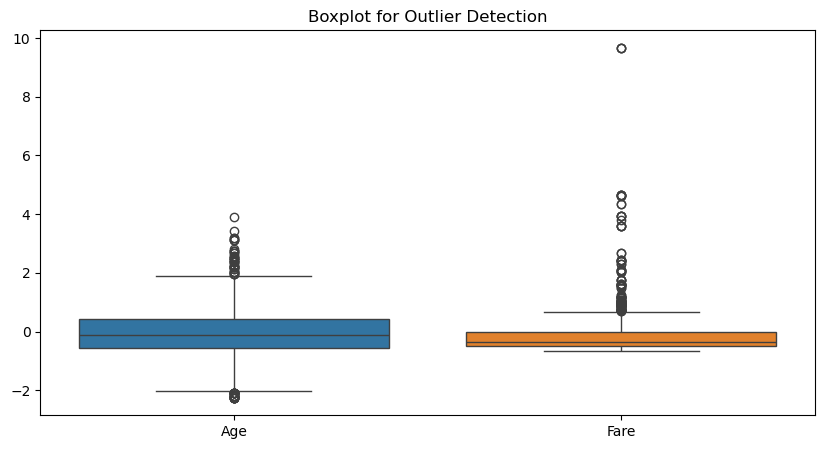

In [16]:
# Detect and Visualize Outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=Dataset_encoded[['Age', 'Fare']])
plt.title("Boxplot for Outlier Detection")
plt.show()


In [18]:
# Remove Outliers using IQR method
Q1 = Dataset_encoded[['Age', 'Fare']].quantile(0.25)
Q3 = Dataset_encoded[['Age', 'Fare']].quantile(0.75)
IQR = Q3 - Q1
Dataset_cleaned = Dataset_encoded[~((Dataset_encoded[['Age', 'Fare']] < (Q1 - 1.5 * IQR)) | 
                                    (Dataset_encoded[['Age', 'Fare']] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"\nShape before removing outliers: {Dataset_encoded.shape}")
print(f"Shape after removing outliers: {Dataset_cleaned.shape}")


Shape before removing outliers: (891, 11)
Shape after removing outliers: (721, 11)


In [19]:
# Save Cleaned Dataset
Dataset_cleaned.to_csv("titanic_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved as 'titanic_cleaned.csv'")


✅ Cleaned dataset saved as 'titanic_cleaned.csv'
